In [21]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import paths
from astropy import constants as const
from astropy import units as u
import os
import glob
from functions import read_data, read_grid

%matplotlib inline

In [22]:
# Select directory to analyze (change as needed)
directory = '100au'  # Options: '10au', '50au', '100au', '200au'
base_path = paths.data / 'PLUTO_runs'
output_dir = os.path.join(base_path, directory, 'out')
os.chdir(output_dir)

print(f"Analyzing directory: {directory}")

Analyzing directory: 100au


In [23]:
# Load and average last 10 data files
data_files = sorted(glob.glob('data.*.dbl.h5'))
last_10_files = data_files[-10:]

print(f"Processing {len(last_10_files)} files")

# Initialize arrays
density_avg = None
vx_avg = None
vz_avg = None

# Read and average
for file in last_10_files:
    grid_temp = read_grid(file)
    data_temp = read_data(file, grid_temp)
    
    if density_avg is None:
        density_avg = data_temp["density"]
        vx_avg = data_temp["v_x"]
        vz_avg = data_temp["v_z"]
    else:
        density_avg += data_temp["density"]
        vx_avg += data_temp["v_x"]
        vz_avg += data_temp["v_z"]

# Calculate averages
n_files = len(last_10_files)
density_avg /= n_files
vx_avg /= n_files
vz_avg /= n_files

print("Data loaded successfully")

Processing 10 files
Data loaded successfully


In [24]:
# Calculate velocity and gradients
v_total = np.sqrt(vx_avg**2 + vz_avg**2)  # in cm/s

# Grid coordinates
R_grid = grid_temp["X"]  # in cm
Z_grid = grid_temp["Z"]  # in cm
r_distance = np.sqrt(R_grid**2 + Z_grid**2)  # in cm

# Convert to AU for plotting
X_AU = (R_grid*u.cm).to(u.AU).value
Z_AU = (Z_grid*u.cm).to(u.AU).value
v_total_kms = (v_total*u.cm/u.s).to(u.km/u.s).value

# Calculate radial gradient of velocity
dv_dr = np.gradient(v_total, axis=1)
dr = np.gradient(R_grid, axis=1)
dv_dr_normalized = dv_dr / (dr + 1e-30)  # Normalized gradient in s^-1

print(f"Velocity range: {v_total_kms.min():.2f} to {v_total_kms.max():.2f} km/s")
print(f"Gradient range: {dv_dr_normalized.min():.2e} to {dv_dr_normalized.max():.2e} s^-1")

Velocity range: 0.00 to 53.83 km/s
Gradient range: -3.66e-05 to 2.19e-05 s^-1


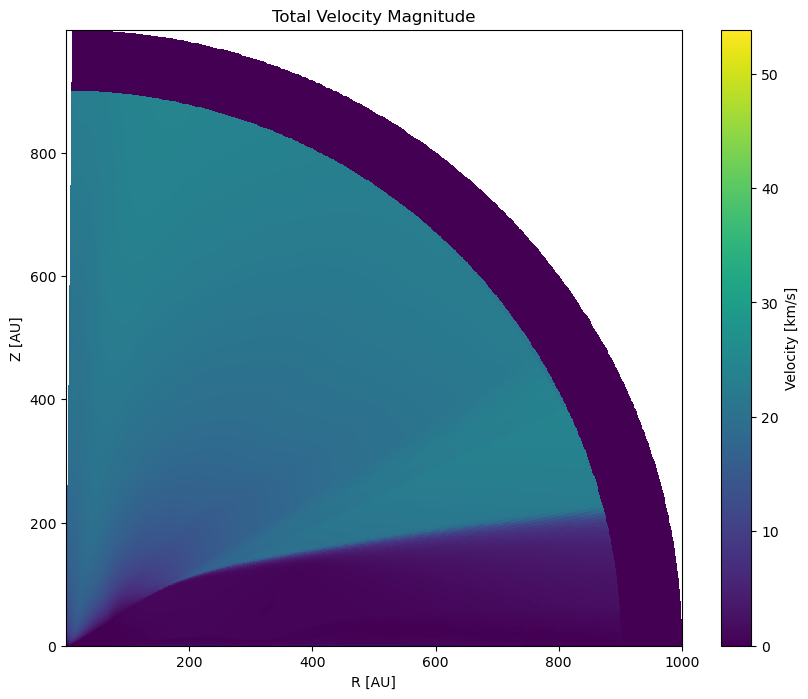

In [25]:
# Plot 1: Velocity magnitude
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(X_AU, Z_AU, v_total_kms, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label='Velocity [km/s]')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Z [AU]')
ax.set_title('Total Velocity Magnitude')
ax.set_aspect('equal')
plt.show()

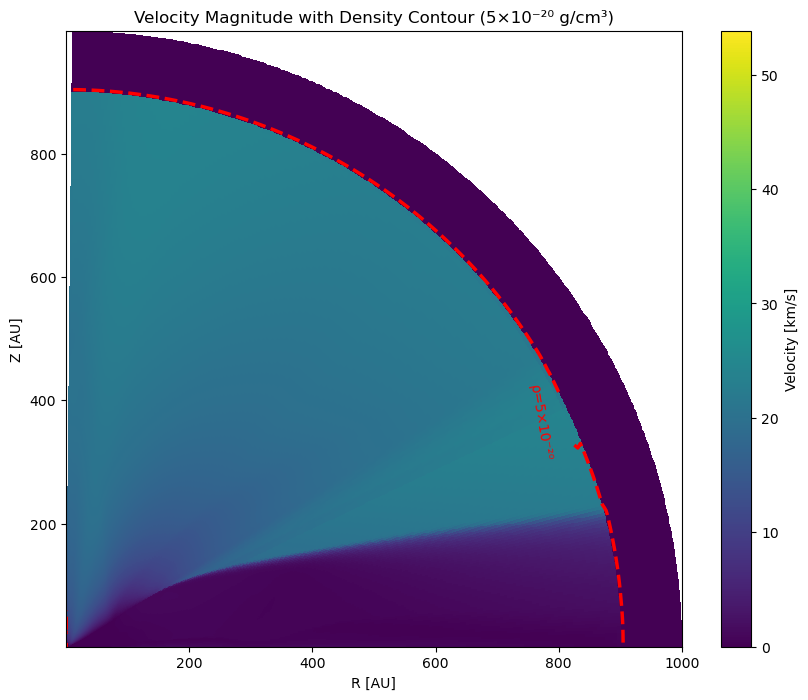

In [39]:
# Plot 1b: Velocity magnitude with density contour overlay
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.pcolormesh(X_AU, Z_AU, v_total_kms, cmap='viridis', shading='auto')
plt.colorbar(im, ax=ax, label='Velocity [km/s]')

# Add density contour at 5e-20 g/cm^3
density_threshold = 1e-22
contour = ax.contour(X_AU, Z_AU, density_avg, levels=[density_threshold], 
                     colors='red', linewidths=2.5, linestyles='dashed')
ax.clabel(contour, inline=True, fontsize=10, fmt='ρ=5×10⁻²⁰')

ax.set_xlabel('R [AU]')
ax.set_ylabel('Z [AU]')
ax.set_title('Velocity Magnitude with Density Contour (5×10⁻²⁰ g/cm³)')
ax.set_aspect('equal')
plt.show()

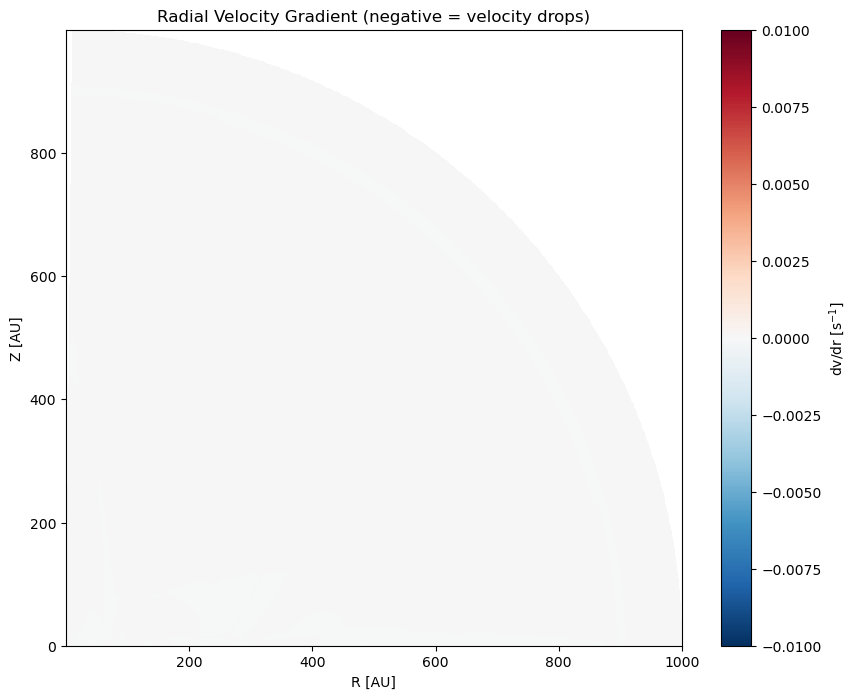

In [26]:
# Plot 2: Radial velocity gradient
fig, ax = plt.subplots(figsize=(10, 8))
# Use symmetric log scale to see both positive and negative gradients
im = ax.pcolormesh(X_AU, Z_AU, dv_dr_normalized, cmap='RdBu_r', 
                   vmin=-0.01, vmax=0.01, shading='auto')
plt.colorbar(im, ax=ax, label='dv/dr [s$^{-1}$]')
ax.set_xlabel('R [AU]')
ax.set_ylabel('Z [AU]')
ax.set_title('Radial Velocity Gradient (negative = velocity drops)')
ax.set_aspect('equal')
plt.show()

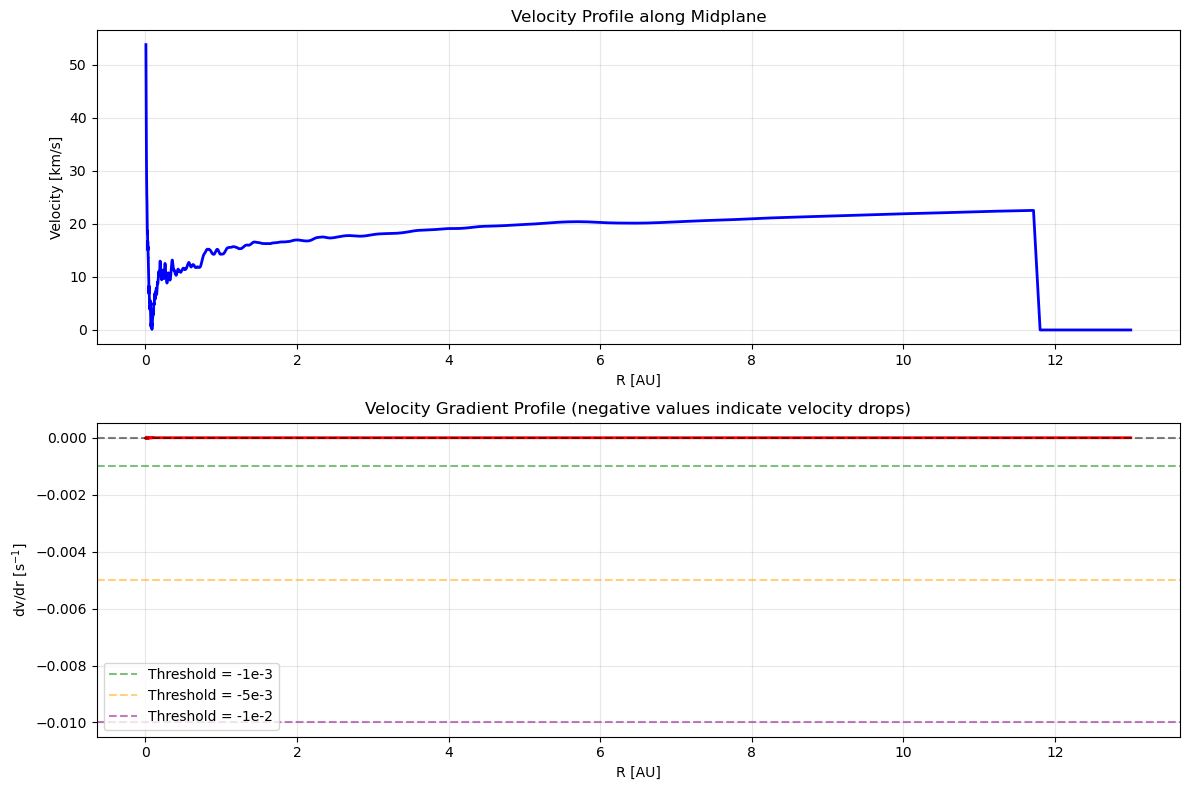

In [27]:
# Plot 3: 1D profiles along midplane (z=0 or lowest z)
midplane_idx = 0  # Lowest z index

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Velocity profile
ax1.plot(X_AU[midplane_idx, :], v_total_kms[midplane_idx, :], 'b-', linewidth=2)
ax1.set_xlabel('R [AU]')
ax1.set_ylabel('Velocity [km/s]')
ax1.set_title('Velocity Profile along Midplane')
ax1.grid(True, alpha=0.3)

# Gradient profile
ax2.plot(X_AU[midplane_idx, :], dv_dr_normalized[midplane_idx, :], 'r-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.axhline(y=-1e-3, color='g', linestyle='--', alpha=0.5, label='Threshold = -1e-3')
ax2.axhline(y=-5e-3, color='orange', linestyle='--', alpha=0.5, label='Threshold = -5e-3')
ax2.axhline(y=-1e-2, color='purple', linestyle='--', alpha=0.5, label='Threshold = -1e-2')
ax2.set_xlabel('R [AU]')
ax2.set_ylabel('dv/dr [s$^{-1}$]')
ax2.set_title('Velocity Gradient Profile (negative values indicate velocity drops)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

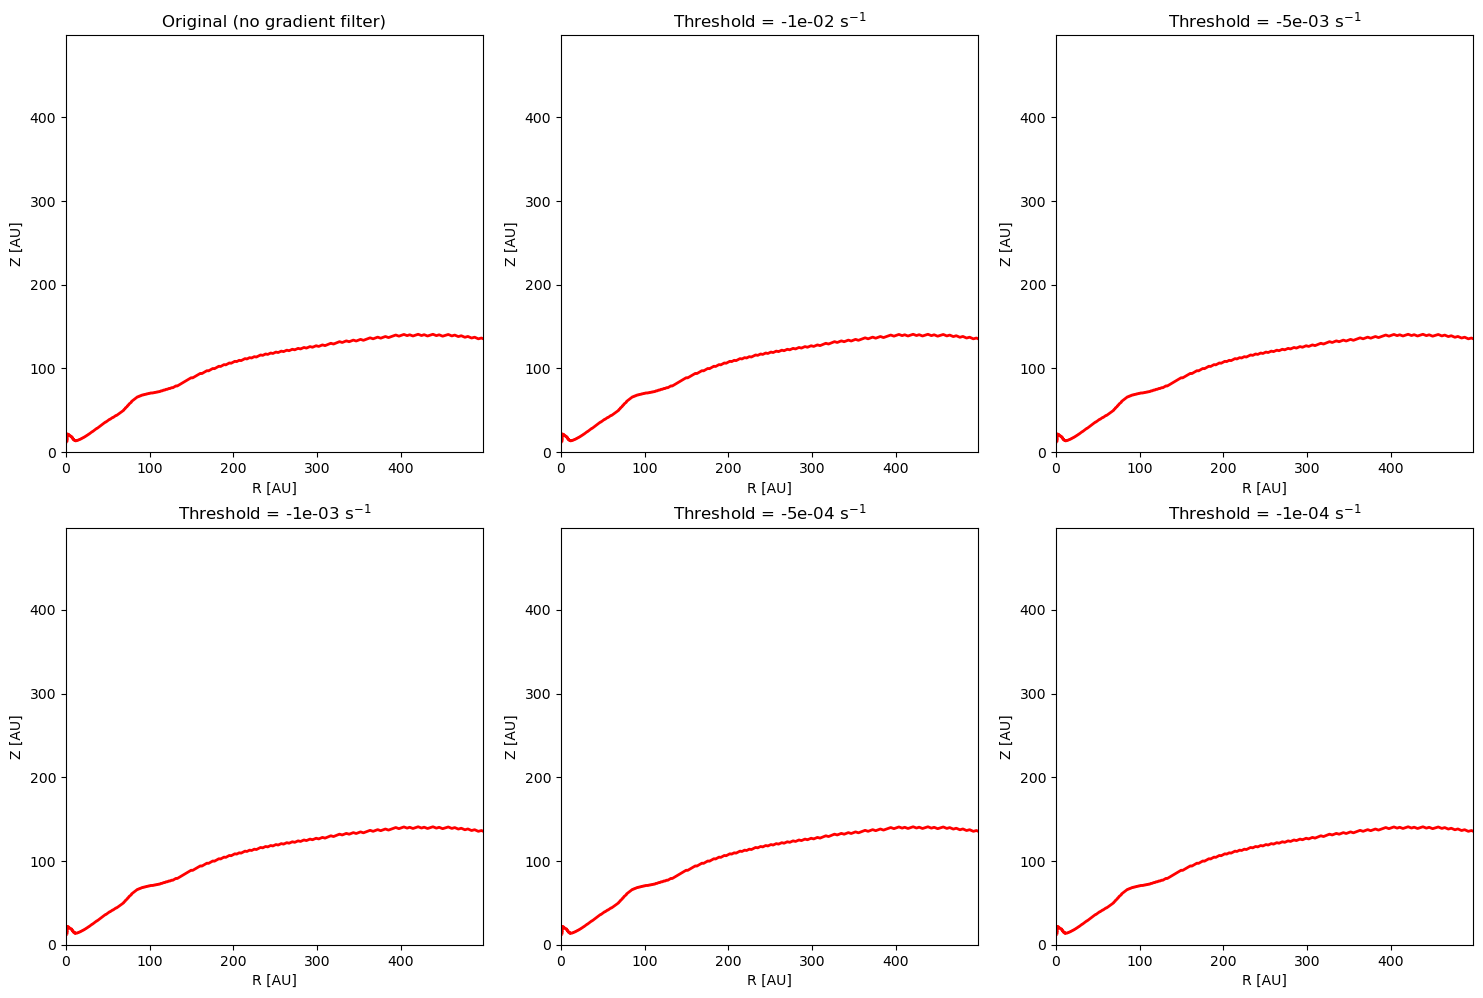

In [28]:
# Interactive threshold testing
# Test different gradient thresholds
gradient_thresholds = [-1e-2, -5e-3, -1e-3, -5e-4, -1e-4]

# Calculate escape velocity
Mstar = 1.0 * const.M_sun
v_escape = np.sqrt(2 * const.G.cgs.value * Mstar.cgs.value / r_distance)
unbound_base = v_total > v_escape

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Plot original unbound region
axes[0].contour(X_AU, Z_AU, unbound_base.astype(float), levels=[0.5], 
                colors='red', linewidths=2)
axes[0].set_title('Original (no gradient filter)')
axes[0].set_xlabel('R [AU]')
axes[0].set_ylabel('Z [AU]')
axes[0].set_aspect('equal')
axes[0].set_xlim(0, X_AU.max()/2)
axes[0].set_ylim(0, Z_AU.max()/2)

# Plot with different thresholds
for i, threshold in enumerate(gradient_thresholds, start=1):
    gradient_mask = dv_dr_normalized > threshold
    unbound_filtered = unbound_base & gradient_mask
    
    axes[i].contour(X_AU, Z_AU, unbound_filtered.astype(float), levels=[0.5], 
                    colors='red', linewidths=2)
    axes[i].set_title(f'Threshold = {threshold:.0e} s$^{{-1}}$')
    axes[i].set_xlabel('R [AU]')
    axes[i].set_ylabel('Z [AU]')
    axes[i].set_aspect('equal')
    axes[i].set_xlim(0, X_AU.max()/2)
    axes[i].set_ylim(0, Z_AU.max()/2)

plt.tight_layout()
plt.show()

In [29]:
# Statistical analysis of gradients in different regions
print("Statistical Analysis of Velocity Gradients:")
print("="*50)

# Define regions based on radius
r_au = (r_distance*u.cm).to(u.AU).value
inner_mask = r_au < 100
middle_mask = (r_au >= 100) & (r_au < 500)
outer_mask = r_au >= 500

for name, mask in [('Inner (<100 AU)', inner_mask), 
                    ('Middle (100-500 AU)', middle_mask),
                    ('Outer (>500 AU)', outer_mask)]:
    grad_region = dv_dr_normalized[mask]
    print(f"\n{name}:")
    print(f"  Mean gradient: {grad_region.mean():.2e} s^-1")
    print(f"  Std gradient: {grad_region.std():.2e} s^-1")
    print(f"  Min gradient: {grad_region.min():.2e} s^-1")
    print(f"  10th percentile: {np.percentile(grad_region, 10):.2e} s^-1")
    print(f"  5th percentile: {np.percentile(grad_region, 5):.2e} s^-1")

Statistical Analysis of Velocity Gradients:

Inner (<100 AU):
  Mean gradient: -1.50e-07 s^-1
  Std gradient: 1.02e-06 s^-1
  Min gradient: -3.66e-05 s^-1
  10th percentile: -3.58e-07 s^-1
  5th percentile: -1.03e-06 s^-1

Middle (100-500 AU):
  Mean gradient: 4.08e-10 s^-1
  Std gradient: 1.44e-09 s^-1
  Min gradient: -2.99e-08 s^-1
  10th percentile: -9.01e-12 s^-1
  5th percentile: -3.37e-11 s^-1

Outer (>500 AU):
  Mean gradient: -6.74e-10 s^-1
  Std gradient: 1.32e-08 s^-1
  Min gradient: -8.65e-07 s^-1
  10th percentile: 0.00e+00 s^-1
  5th percentile: 0.00e+00 s^-1


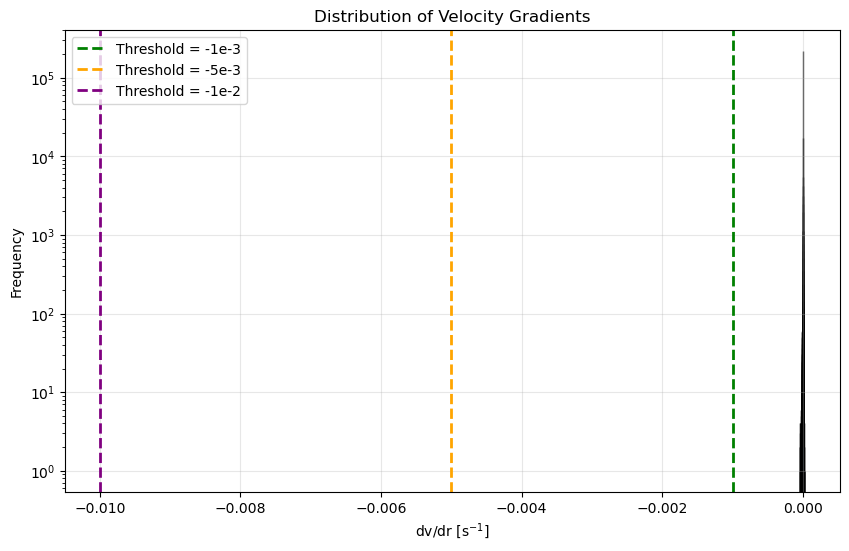

In [30]:
# Histogram of gradients to see distribution
fig, ax = plt.subplots(figsize=(10, 6))

# Flatten and filter out extreme values for better visualization
grad_flat = dv_dr_normalized.flatten()
grad_filtered = grad_flat[(grad_flat > -0.1) & (grad_flat < 0.1)]

ax.hist(grad_filtered, bins=200, alpha=0.7, edgecolor='black')
ax.axvline(x=-1e-3, color='g', linestyle='--', linewidth=2, label='Threshold = -1e-3')
ax.axvline(x=-5e-3, color='orange', linestyle='--', linewidth=2, label='Threshold = -5e-3')
ax.axvline(x=-1e-2, color='purple', linestyle='--', linewidth=2, label='Threshold = -1e-2')
ax.set_xlabel('dv/dr [s$^{-1}$]')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Velocity Gradients')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()